# Inference Check

In [1]:
import os

os.chdir("..")

## Inference Visualization

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import pandas as pd
from numpy.typing import NDArray
from PIL import Image


def plot_inference(inference: pd.DataFrame, img: NDArray) -> None:
    fig, ax = plt.subplots(1, figsize=(10, 8))
    ax.imshow(img)

    for _, pred in inference.iterrows():
        xmin, ymin, xmax, ymax = pred["xmin"], pred["ymin"], pred["xmax"], pred["ymax"]

        rect = patches.Rectangle(
            (xmin, ymin),
            xmax - xmin,
            ymax - ymin,
            linewidth=2,
            edgecolor="red",
            facecolor="none",
        )

        confidence = pred["confidence"]
        ax.add_patch(rect)
        ax.text(
            xmin,
            ymin,
            f"{confidence:.2f}",
            color="white",
            bbox=dict(facecolor="red", alpha=0.5),
        )

    plt.axis("off")
    plt.show()

Get the data paths:

In [3]:
from pathlib import Path

IMAGES = list(Path("../data_det_public/data_det_public/img/aachen").glob("*.png"))
INFERENCES = list(Path("output_predictions").glob("*.csv"))

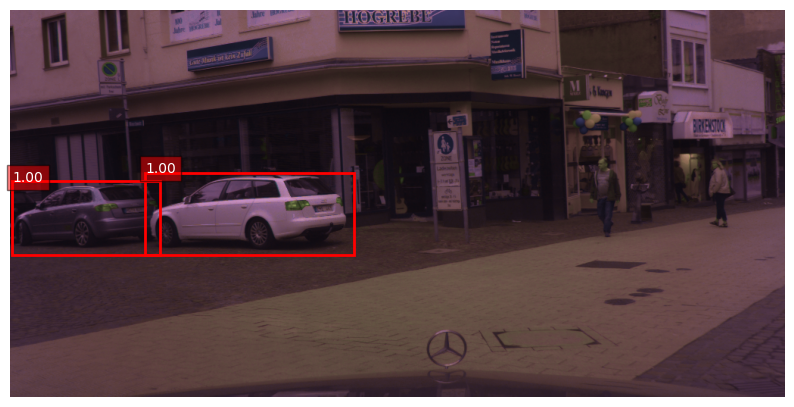

In [18]:
SAMPLE_IDX = 17

img = Image.open(str(IMAGES[SAMPLE_IDX]))
img = np.array(img)
df = pd.read_csv(str(INFERENCES[SAMPLE_IDX]))

plot_inference(df, img)